In [41]:
import numpy as np
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.plot import show
import matplotlib.pyplot as plt
from pathlib import Path

from datetime import datetime, timezone, timedelta

from scipy.ndimage import rotate as ndimage_rotate

import numba
import time
# Resolve absolute path relative to the notebook's location
NOTEBOOK_DIR = Path().resolve()           # notebooks/
PROJECT_ROOT = NOTEBOOK_DIR.parent        # dem_toolbox/

DEM_PATH = PROJECT_ROOT / "data/raw/GLO30_Oberaletsch_area_tile_00_00_W7p8000S46p3000_E8p2000N46p5000.tif"

print(DEM_PATH)
print(DEM_PATH.exists())   # must print True
# Oberaletsch is in UTM zone 32N
TARGET_CRS = "EPSG:32632"
REPROJECTED_PATH = PROJECT_ROOT / "data/temp/GLO30_Oberaletsch_area_UTM32N.tif"

with rasterio.open(DEM_PATH) as src:
    transform, width, height = calculate_default_transform(
        src.crs, TARGET_CRS, src.width, src.height, *src.bounds
    )
    profile = src.profile.copy()
    profile.update(crs=TARGET_CRS, transform=transform, width=width, height=height)

    with rasterio.open(REPROJECTED_PATH, "w", **profile) as dst:
        reproject(
            source=rasterio.band(src, 1),
            destination=rasterio.band(dst, 1),
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs=TARGET_CRS,
            resampling=Resampling.bilinear
        )

# Reload reprojected DEM
with rasterio.open(REPROJECTED_PATH) as src:
    dem = src.read(1).astype(np.float32)
    profile = src.profile
    transform = src.transform
    crs = src.crs
    res_x, res_y = src.res
    bounds = src.bounds

dem[dem == 0] = np.nan   # mask fill/ocean pixels

print("=== Reprojected DEM ===")
print(f"CRS        : {crs}")
print(f"Resolution : {res_x:.1f} x {res_y:.1f} m")
print(f"Shape      : {dem.shape}")
print(f"Elev range (masked): {np.nanmin(dem):.1f} – {np.nanmax(dem):.1f} m")


D:\Projects\dem_toolbox\data\raw\GLO30_Oberaletsch_area_tile_00_00_W7p8000S46p3000_E8p2000N46p5000.tif
True
=== Reprojected DEM ===
CRS        : EPSG:32632
Resolution : 23.6 x 23.6 m
Shape      : (959, 1317)
Elev range (masked): 633.0 – 4143.4 m


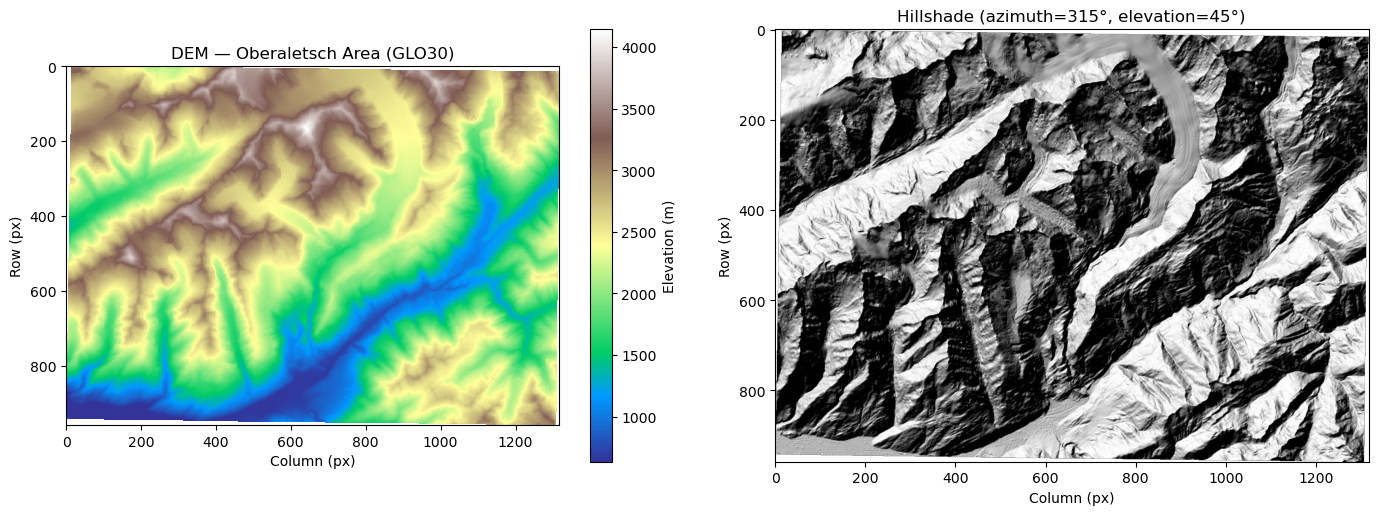

In [42]:
# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im = axes[0].imshow(dem, cmap="terrain", interpolation="none")
plt.colorbar(im, ax=axes[0], label="Elevation (m)")
axes[0].set_title("DEM — Oberaletsch Area (GLO30)")
axes[0].set_xlabel("Column (px)")
axes[0].set_ylabel("Row (px)")

# Hillshade for visual context
from matplotlib.colors import LightSource
ls = LightSource(azdeg=315, altdeg=45)
hillshade = ls.hillshade(dem, vert_exag=2, dx=res_x, dy=res_y)
axes[1].imshow(hillshade, cmap="gray")
axes[1].set_title("Hillshade (azimuth=315°, elevation=45°)")
axes[1].set_xlabel("Column (px)")
axes[1].set_ylabel("Row (px)")

plt.tight_layout()
plt.show()

In [48]:
# --- Sun position from scratch (Meeus/NOAA equations) ---
def sun_position(dt: datetime, lat: float, lon: float) -> tuple[float, float]:
    """Returns (azimuth_deg, elevation_deg). Azimuth clockwise from North."""
    jd = (dt - datetime(2000, 1, 1, 12, tzinfo=timezone.utc)).total_seconds() / 86400.0
    T = jd / 36525.0

    L = (280.46646 + 36000.76983 * T) % 360
    M = np.radians((357.52911 + 35999.05029 * T) % 360)
    C = (1.914602 - 0.004817 * T) * np.sin(M) + 0.019993 * np.sin(2 * M)
    lon_sun = np.radians(L + C)

    obliq = np.radians(23.439 - 0.0000004 * jd)
    decl = np.arcsin(np.sin(obliq) * np.sin(lon_sun))

    eot = 4 * np.degrees(lon_sun - np.radians(L))
    utc_min = dt.hour * 60 + dt.minute + dt.second / 60
    solar_noon = 720 - 4 * lon - eot
    hour_angle = np.radians((utc_min - solar_noon) * 0.25)

    lat_r = np.radians(lat)
    sin_elev = (np.sin(lat_r) * np.sin(decl)
              + np.cos(lat_r) * np.cos(decl) * np.cos(hour_angle))
    elevation = np.degrees(np.arcsin(np.clip(sin_elev, -1, 1)))

    cos_az = ((np.sin(decl) - np.sin(lat_r) * sin_elev)
             / (np.cos(lat_r) * np.cos(np.arcsin(np.clip(sin_elev, -1, 1))) + 1e-10))
    azimuth = np.degrees(np.arccos(np.clip(cos_az, -1, 1)))
    if hour_angle > 0:
        azimuth = 360 - azimuth

    return azimuth, elevation


def rotate_dem(dem: np.ndarray, sun_azimuth: float) -> np.ndarray:
    """
    Rotate DEM so sun comes from directly above (along columns, row 0).
    Sun azimuth is clockwise from North.
    After rotation, horizon sweep always runs top → bottom.
    """
    # Convert azimuth (CW from N) to scipy rotation angle (CCW from E)
    angle = -(sun_azimuth - 180)
    rotated = ndimage_rotate(dem, angle=angle, reshape=True, order=1, cval=np.nan)
    return rotated

def sweep_column(elevations: np.ndarray, resolution: float, sun_elev_deg: float) -> tuple:
    """
    Correct O(n) horizon sweep.
    For each pixel i, horizon angle = max over all j < i of:
        arctan((elev[j] - elev[i]) / ((i-j) * resolution))
    Running max is updated by comparing current pixel with all previous
    via the recurrence: as i increases, recompute angle from best j so far.
    """
    n = len(elevations)
    horizon_angle = np.full(n, -np.inf)
    shadow = np.zeros(n, dtype=bool)
    sun_elev_rad = np.radians(sun_elev_deg)

    # Track the highest horizon angle seen, accounting for distance decay
    # We must recompute from scratch — use vectorised NumPy per pixel
    # (Numba will make this fast later)
    for i in range(1, n):
        if np.isnan(elevations[i]):
            continue

        # All valid previous pixels
        prev = np.arange(0, i)
        prev_elev = elevations[prev]
        valid_prev = ~np.isnan(prev_elev)

        if not valid_prev.any():
            continue

        dists = (i - prev[valid_prev]) * resolution
        angles = np.arctan2(
            prev_elev[valid_prev] - elevations[i],
            dists
        )
        max_h = angles.max()
        horizon_angle[i] = max_h
        shadow[i] = max_h > sun_elev_rad

    return horizon_angle, shadow


@numba.njit
def sweep_column_numba(elevations, resolution, sun_elev_rad):
    """
    True O(n) horizon sweep — Numba JIT compiled.

    For each pixel i, the horizon angle from pixel j to i is:
        arctan((z[j] - z[i]) / ((i-j) * res))

    Running max works because:
        - When we move from i to i+1, all previous angles decrease
          (distance increases) EXCEPT the new pixel i which is now added
        - We therefore need to recheck the full history — true O(n) running
          max requires a monotonic stack approach

    Here we use the correct stack-based O(n) algorithm:
        maintain a stack of candidate shadow casters (pixels that could
        still cast shadow further down). A pixel is popped when a taller
        closer pixel makes it irrelevant.
    """
    n = len(elevations)
    shadow = numba.typed.List.empty_list(numba.boolean)
    for _ in range(n):
        shadow.append(False)

    horizon_angle = np.full(n, -np.inf)

    # Monotonic stack: stores (row_index, elevation) of candidate casters
    # Stack maintains decreasing horizon angles (steepest at top)
    stack_idx = np.full(n, -1, dtype=np.int64)
    stack_elev = np.full(n, -np.inf)
    stack_top = -1

    for i in range(n):
        if np.isnan(elevations[i]):
            continue

        # Compute horizon angle from each stack candidate
        max_h = -np.inf
        for k in range(stack_top, -1, -1):
            j = stack_idx[k]
            dist = (i - j) * resolution
            angle = np.arctan2(stack_elev[k] - elevations[i], dist)
            if angle > max_h:
                max_h = angle

        if i > 0:
            horizon_angle[i] = max_h
            if max_h > sun_elev_rad:
                shadow[i] = True

        # Push current pixel onto stack
        # Pop pixels that can no longer cast shadow farther than current
        while stack_top >= 0:
            j = stack_idx[stack_top]
            dist = (i - j) * resolution
            if dist > 0:
                angle_from_j = np.arctan2(stack_elev[stack_top] - elevations[i], dist)
                if stack_elev[stack_top] <= elevations[i]:
                    stack_top -= 1  # current pixel dominates, pop
                else:
                    break
            else:
                break

        stack_top += 1
        stack_idx[stack_top] = i
        stack_elev[stack_top] = elevations[i]

    return horizon_angle, shadow


# --- Simpler but correct: vectorised NumPy O(n) with broadcasted angles ---
# (fallback reference implementation, cleaner)
def sweep_column_numpy_fast(elevations, resolution, sun_elev_deg):
    """
    Vectorised NumPy — still O(n²) memory but fast for moderate n.
    Use as ground truth to validate Numba version.
    """
    n = len(elevations)
    shadow = np.zeros(n, dtype=bool)
    horizon_angle = np.full(n, -np.inf)
    sun_elev_rad = np.radians(sun_elev_deg)

    for i in range(1, n):
        if np.isnan(elevations[i]):
            continue
        j = np.arange(0, i)
        valid = ~np.isnan(elevations[j])
        if not valid.any():
            continue
        dists = (i - j[valid]) * resolution
        angles = np.arctan2(elevations[j[valid]] - elevations[i], dists)
        max_h = angles.max()
        horizon_angle[i] = max_h
        shadow[i] = max_h > sun_elev_rad

    return horizon_angle, shadow


def compute_shadow_2d(dem_rotated: np.ndarray, resolution: float, sun_elev_deg: float) -> np.ndarray:
    """
    Apply horizon sweep to every column of the rotated DEM.
    Returns shadow mask (same shape as dem_rotated).
    """
    sun_elev_rad = np.radians(sun_elev_deg)
    n_rows, n_cols = dem_rotated.shape
    shadow_rotated = np.zeros((n_rows, n_cols), dtype=bool)

    for col in range(n_cols):
        column = dem_rotated[:, col].copy()
        _, s = sweep_column_numba(column, resolution, sun_elev_rad)
        shadow_rotated[:, col] = np.array(list(s))

    return shadow_rotated


def unrotate_mask(shadow_rotated: np.ndarray, sun_azimuth: float,
                  original_shape: tuple) -> np.ndarray:
    """Rotate shadow mask back to original DEM orientation and crop."""
    angle = (sun_azimuth - 180)  # ← + NOT - ! OPPOSITE of rotate_dem
    unrotated = ndimage_rotate(shadow_rotated.astype(float), angle=angle,
                              reshape=True, order=0, cval=0)
    # Crop to original shape (center crop)
    r_orig, c_orig = original_shape
    r_rot, c_rot = unrotated.shape
    r_start = (r_rot - r_orig) // 2
    c_start = (c_rot - c_orig) // 2
    shadow_final = unrotated[r_start:r_start+r_orig, c_start:c_start+c_orig]
    return shadow_final.astype(bool)




In [50]:
# --- AOI center coordinates ---
LAT, LON = 46.40, 8.00   # Oberaletsch center

# --- Compute sun positions for a full summer day ---
date = datetime(2026, 7, 15, tzinfo=timezone.utc)
times = [date + timedelta(minutes=60 * i) for i in range(24)]

azimuths, elevations = [], []
for t in times:
    az, el = sun_position(t, LAT, LON)
    azimuths.append(az)
    elevations.append(el)

azimuths = np.array(azimuths)
elevations = np.array(elevations)
hours = np.array([t.hour + t.minute/60 for t in times])

# Only daytime
daytime = elevations > 0

print(f"Sunrise : ~{hours[daytime][0]:.1f} UTC")
print(f"Sunset  : ~{hours[daytime][-1]:.1f} UTC")
print(f"Max elevation: {elevations.max():.1f}° at {hours[elevations.argmax()]:.1f} UTC")
print(f"Azimuth at max elevation: {azimuths[elevations.argmax()]:.1f}°")

Sunrise : ~4.0 UTC
Sunset  : ~19.0 UTC
Max elevation: 64.4° at 11.0 UTC
Azimuth at max elevation: 164.1°


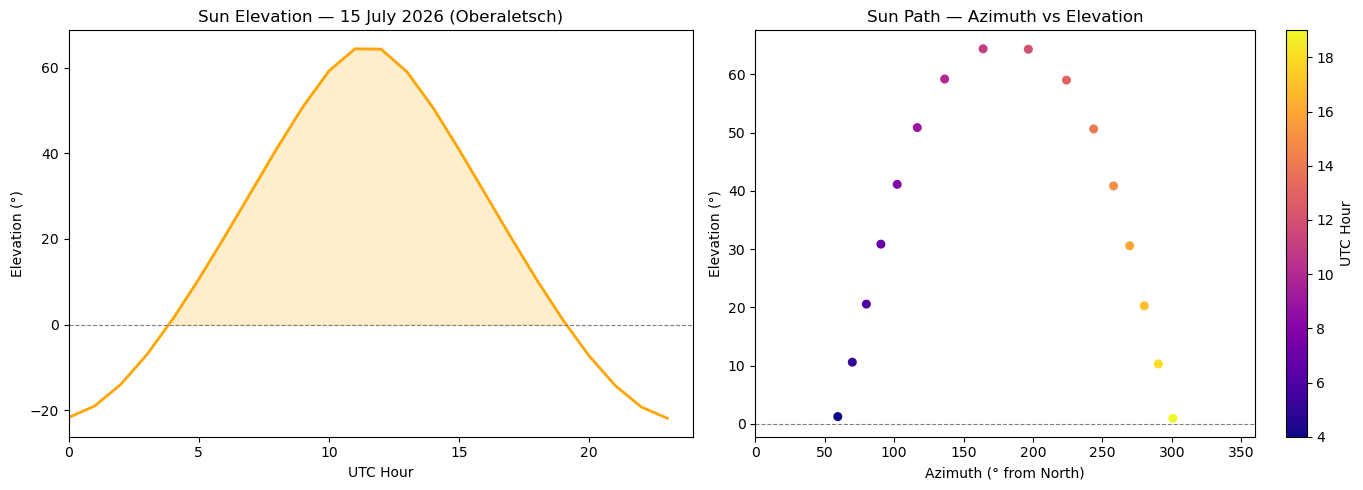

In [44]:
# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elevation over time
axes[0].plot(hours, elevations, color="orange", lw=2)
axes[0].axhline(0, color="gray", lw=0.8, linestyle="--")
axes[0].fill_between(hours, 0, elevations, where=elevations > 0, alpha=0.2, color="orange")
axes[0].set_title("Sun Elevation — 15 July 2026 (Oberaletsch)")
axes[0].set_xlabel("UTC Hour")
axes[0].set_ylabel("Elevation (°)")
axes[0].set_xlim(0, 24)

# Sun path: azimuth vs elevation (polar-style on cartesian)
ax = axes[1]
sc = ax.scatter(azimuths[daytime], elevations[daytime],
                c=hours[daytime], cmap="plasma", s=30, zorder=3)
plt.colorbar(sc, ax=ax, label="UTC Hour")
ax.set_title("Sun Path — Azimuth vs Elevation")
ax.set_xlabel("Azimuth (° from North)")
ax.set_ylabel("Elevation (°)")
ax.set_xlim(0, 360)
ax.axhline(0, color="gray", lw=0.8, linestyle="--")

plt.tight_layout()
plt.show()

In [46]:
# --- Test with sun at solar noon ---
az_noon, el_noon = sun_position(
    datetime(2026, 7, 15, 11, 0, tzinfo=timezone.utc), LAT, LON
)
print(f"Sun at noon: azimuth={az_noon:.1f}°, elevation={el_noon:.1f}°")

dem_rotated = rotate_dem(dem, az_noon)

print(f"Original shape : {dem.shape}")
print(f"Rotated shape  : {dem_rotated.shape}  (larger due to padding)")


Sun at noon: azimuth=164.1°, elevation=64.4°
Original shape : (959, 1317)
Rotated shape  : (1283, 1530)  (larger due to padding)


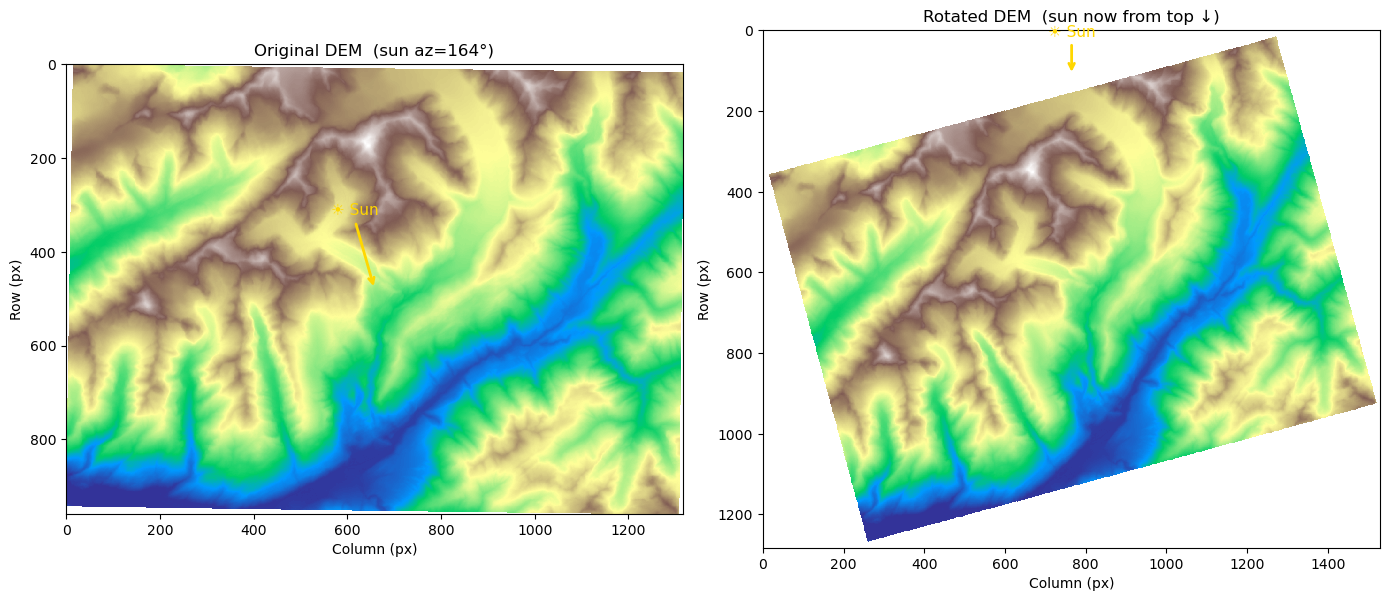

In [47]:
# --- Visualise ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(dem, cmap="terrain", interpolation="none")
axes[0].set_title(f"Original DEM  (sun az={az_noon:.0f}°)")
axes[0].set_xlabel("Column (px)")
axes[0].set_ylabel("Row (px)")
# Draw sun direction arrow from edge toward center
cx, cy = dem.shape[1]//2, dem.shape[0]//2
dx = np.sin(np.radians(az_noon)) * 150
dy = -np.cos(np.radians(az_noon)) * 150
axes[0].annotate("", xy=(cx, cy), xytext=(cx - dx, cy - dy),
    arrowprops=dict(arrowstyle="->", color="gold", lw=2))
axes[0].text(cx - dx, cy - dy - 15, "☀ Sun", color="gold",
             ha="center", fontsize=11)

axes[1].imshow(dem_rotated, cmap="terrain", interpolation="none")
axes[1].set_title("Rotated DEM  (sun now from top ↓)")
axes[1].set_xlabel("Column (px)")
axes[1].set_ylabel("Row (px)")
# Arrow always points straight down after rotation
rc, rr = dem_rotated.shape[1]//2, 30
axes[1].annotate("", xy=(rc, rr + 80), xytext=(rc, rr),
    arrowprops=dict(arrowstyle="->", color="gold", lw=2))
axes[1].text(rc, rr - 15, "☀ Sun", color="gold", ha="center", fontsize=11)

plt.tight_layout()
plt.show()

Morning sun: az=80.0° el=20.6°
Rotated shape: (1464, 1173)
Computing shadows...
Done: 6.6s | Fraction: 38.2%


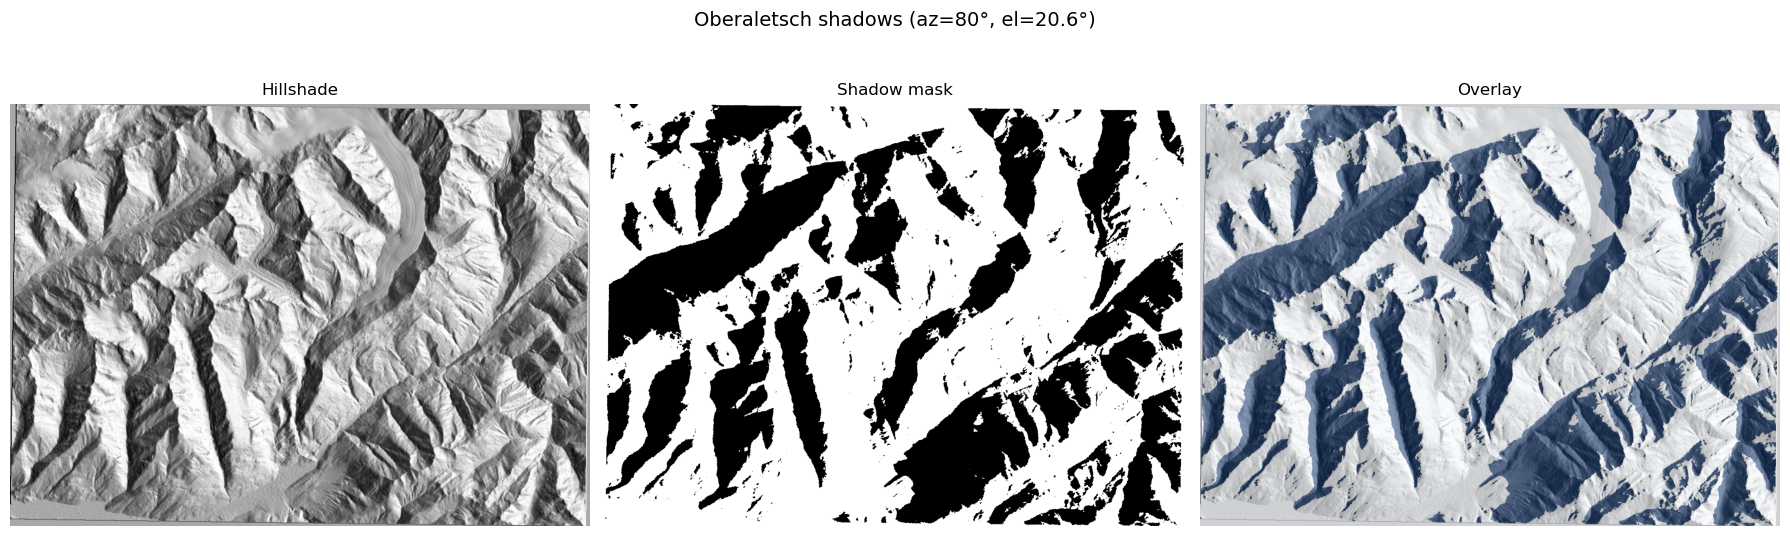

In [54]:
# === SETUP (run once) ===
RESOLUTION = float(res_x)
LAT, LON = 46.4, 8.0
dt_morning = datetime(2026, 7, 15, 6, 0, tzinfo=timezone.utc)

az_morning, el_morning = sun_position(dt_morning, LAT, LON)
print(f"Morning sun: az={az_morning:.1f}° el={el_morning:.1f}°")

# Rotate DEM
dem_rotated_morning = rotate_dem(dem, az_morning)
print(f"Rotated shape: {dem_rotated_morning.shape}")

# === COMPUTE SHADOWS ===
print("Computing shadows...")
t0 = time.time()
shadow_rotated = compute_shadow_2d(dem_rotated_morning, RESOLUTION, el_morning)
shadow_final = unrotate_mask(shadow_rotated, az_morning, dem.shape)
print(f"Done: {time.time()-t0:.1f}s | Fraction: {shadow_final.mean():.1%}")

# === VISUALIZE ===
from matplotlib.colors import LightSource
ls = LightSource(azdeg=az_morning, altdeg=el_morning)
hillshade = ls.hillshade(np.nan_to_num(dem), vert_exag=2, dx=RESOLUTION, dy=RESOLUTION)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(hillshade, cmap="gray"); axes[0].set_title("Hillshade"); axes[0].axis("off")
axes[1].imshow(shadow_final, cmap="gray_r"); axes[1].set_title("Shadow mask"); axes[1].axis("off")
axes[2].imshow(hillshade, cmap="gray"); axes[2].imshow(shadow_final, alpha=0.5, cmap="Blues"); axes[2].set_title("Overlay"); axes[2].axis("off")
plt.suptitle(f"Oberaletsch shadows (az={az_morning:.0f}°, el={el_morning:.1f}°)", fontsize=14)
plt.tight_layout()
plt.show()
